In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE

np.random.seed(42)

In [19]:
n_samples = 120

def generate_cluster(mean, std, n):
    return np.random.normal(loc=mean, scale=std, size=(n, len(mean)))

tech_part = np.vstack([
    generate_cluster([30, 50, 10, 2000], [5, 10, 2, 500], n_samples // 2),
    generate_cluster([80, 180, 40, 9000], [5, 10, 2, 500], n_samples // 2)
])

tech_part = np.clip(tech_part, [10,20,5,1000], [100,200,50,10000])

sem_part = np.zeros((n_samples, 4), dtype=int)
sem_part[:n_samples//2, 0] = 1
sem_part[n_samples//2:, 1] = 1
sem_part[:,2] = np.random.randint(0,2,n_samples)
sem_part[:,3] = np.random.randint(0,2,n_samples)

struct_part = np.column_stack([
    np.random.randint(3,15,n_samples),
    np.random.randint(2,20,n_samples)
])

df = pd.DataFrame(
    np.hstack([tech_part, sem_part, struct_part]),
    columns=[
        'diameter','length','mass','speed',
        'is_motor','is_turbine','has_magnet','has_cooling',
        'num_components','num_connections'
    ]
)

df[['is_motor','is_turbine','has_magnet','has_cooling']] = \
df[['is_motor','is_turbine','has_magnet','has_cooling']].astype(int)

labels = (
    df["is_motor"]*2 +
    df["has_magnet"]*2 +
    (df["diameter"]>60).astype(int) +
    (df["speed"]>6000).astype(int) +
    (df["num_components"]>8).astype(int)
).astype(int).values

print("Label distribution:", np.bincount(labels))
df.head()

Label distribution: [ 0  0 30 27 27 36]


,diameter,length,mass,speed,is_motor,is_turbine,has_magnet,has_cooling,num_components,num_connections
0,32.483571,48.617357,11.295377,2761.514928,1,0,0,0,6.0,8.0
1,28.829233,47.658630,13.158426,2383.717365,1,0,1,0,3.0,7.0
2,27.652628,55.425600,9.073165,1767.135123,1,0,1,1,6.0,2.0
3,31.209811,30.867198,6.550164,1718.856235,1,0,1,1,9.0,18.0
4,24.935844,53.142473,8.183952,1293.848149,1,0,0,1,13.0,12.0


In [20]:
def build_features(df):
    tech = df[['diameter','length','mass','speed']].values
    semantic = df[['is_motor','is_turbine','has_magnet','has_cooling']].values
    structural = df[['num_components','num_connections']].values
    return tech, semantic, structural

tech, semantic, structural = build_features(df)

tech_scaled = StandardScaler().fit_transform(tech)
struct_scaled = StandardScaler().fit_transform(structural)

In [21]:
def cosine_sim(X):
    S = cosine_similarity(X)
    np.fill_diagonal(S, 0.0)
    return S

def semantic_sim(X):
    D = pairwise_distances(X, metric='jaccard')
    S = 1 - D
    np.fill_diagonal(S, 0.0)
    return S

def structural_sim(X):
    S = cosine_similarity(X)
    np.fill_diagonal(S, 0.0)
    return S

S_cos = cosine_sim(tech_scaled)
S_sem = semantic_sim(semantic)
S_struct = structural_sim(struct_scaled)

/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [22]:
def normalize(S):
    S_min = S.min()
    S_max = S.max()
    return (S - S_min) / (S_max - S_min)

S_cos = normalize(S_cos)
S_sem = normalize(S_sem)
S_struct = normalize(S_struct)

In [23]:
def hybrid_sim(S_tech, S_sem, S_struct, a, b, g):
    return a*S_sem + b*S_tech + g*S_struct

In [24]:
def precision_at_k(sim_matrix, labels, k=5):
    scores = []
    for i in range(len(labels)):
        sims = sim_matrix[i]
        idx = np.argsort(sims)[::-1][:k]
        scores.append((labels[idx]==labels[i]).sum()/k)
    return np.mean(scores)

def mean_reciprocal_rank(sim_matrix, labels):
    rr = []
    for i in range(len(labels)):
        sims = sim_matrix[i]
        idx = np.argsort(sims)[::-1]
        for rank, j in enumerate(idx,1):
            if labels[j]==labels[i]:
                rr.append(1/rank)
                break
    return np.mean(rr)

In [25]:
best_score = -1
best_weights = (0.4,0.4,0.2)

for a in np.linspace(0.3,0.6,7):
    for b in np.linspace(0.3,0.6,7):
        g = 1-(a+b)
        if g<0: continue
        
        S_h = hybrid_sim(S_cos,S_sem,S_struct,a,b,g)
        score = precision_at_k(S_h, labels)
        
        if score > best_score:
            best_score = score
            best_weights = (a,b,g)

print("Best weights:", best_weights)
print("Best score:", best_score)

Best weights: (np.float64(0.44999999999999996), np.float64(0.39999999999999997), np.float64(0.15000000000000013))
Best score: 0.8316666666666668


In [26]:
a,b,g = best_weights

S_hybrid = hybrid_sim(S_cos,S_sem,S_struct,a,b,g)

methods = {
    "Technical": S_cos,
    "Semantic": S_sem,
    "Structural": S_struct,
    "Hybrid": S_hybrid
}

K_list = [3,5,10]

results = {k:{} for k in K_list}
mrr = {}

for name,S in methods.items():
    for k in K_list:
        results[k][name] = precision_at_k(S,labels,k)
    mrr[name] = mean_reciprocal_rank(S,labels)

print(results)
print(mrr)

{3: {'Technical': np.float64(0.27777777777777773), 'Semantic': np.float64(0.5138888888888888), 'Structural': np.float64(0.5416666666666666), 'Hybrid': np.float64(0.8888888888888888)}, 5: {'Technical': np.float64(0.25333333333333335), 'Semantic': np.float64(0.48166666666666663), 'Structural': np.float64(0.5083333333333333), 'Hybrid': np.float64(0.8316666666666668)}, 10: {'Technical': np.float64(0.25083333333333335), 'Semantic': np.float64(0.4891666666666667), 'Structural': np.float64(0.4741666666666667), 'Hybrid': np.float64(0.6275)}}
{'Technical': np.float64(0.48991567460317464), 'Semantic': np.float64(0.7013888888888888), 'Structural': np.float64(0.7518948412698413), 'Hybrid': np.float64(0.9958333333333333)}


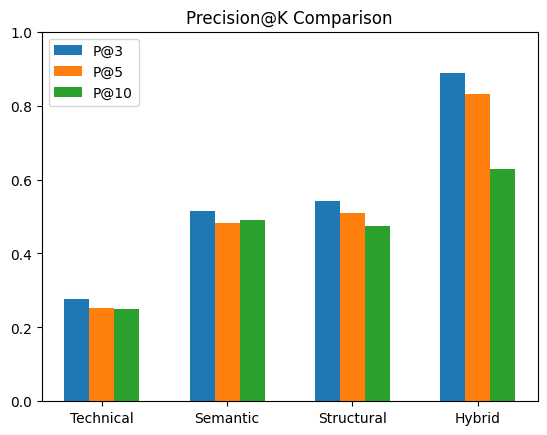

In [27]:
labels_methods = list(methods.keys())
x = np.arange(len(labels_methods))
width = 0.2

plt.figure()

for i,k in enumerate(K_list):
    vals = [results[k][m] for m in labels_methods]
    plt.bar(x+(i-1)*width, vals, width, label=f"P@{k}")

plt.xticks(x, labels_methods)
plt.ylim(0,1)
plt.legend()
plt.title("Precision@K Comparison")
plt.show()

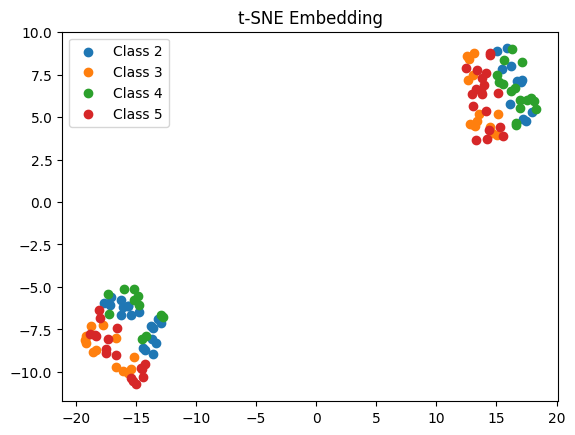

In [28]:
combined = np.hstack([tech_scaled, semantic, struct_scaled])

tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(combined)

plt.figure()

for lbl in np.unique(labels):
    idx = labels==lbl
    plt.scatter(X_2d[idx,0], X_2d[idx,1], label=f"Class {lbl}")

plt.legend()
plt.title("t-SNE Embedding")
plt.show()

In [29]:
table_2 = pd.DataFrame({
    "Method":["Cosine","Semantic","Structural","Hybrid"],
    "P@5":[results[5]["Technical"],results[5]["Semantic"],results[5]["Structural"],results[5]["Hybrid"]],
    "P@10":[results[10]["Technical"],results[10]["Semantic"],results[10]["Structural"],results[10]["Hybrid"]],
    "MRR":[mrr["Technical"],mrr["Semantic"],mrr["Structural"],mrr["Hybrid"]]
})

table_2

,Method,P@5,P@10,MRR
0,Cosine,0.253333,0.250833,0.489916
1,Semantic,0.481667,0.489167,0.701389
2,Structural,0.508333,0.474167,0.751895
3,Hybrid,0.831667,0.627500,0.995833


In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X = np.hstack([tech_scaled, semantic, struct_scaled])
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- kNN ---
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

knn_prob = knn.predict_proba(X_test)

# --- Random Forest ---
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)

# ✅ FIXED AUC (multiclass)
knn_auc = roc_auc_score(y_test, knn_prob, multi_class='ovr')
rf_auc = roc_auc_score(y_test, rf_prob, multi_class='ovr')

print("kNN AUC:", knn_auc)
print("RF AUC:", rf_auc)

kNN AUC: 0.9613095238095237
RF AUC: 1.0


In [31]:
pd.DataFrame({
    "Method":["Technical","Semantic","Hybrid"],
    "Precision@10":[
        results[10]["Technical"],
        results[10]["Semantic"],
        results[10]["Hybrid"]
    ]
})

,Method,Precision@10
0,Technical,0.250833
1,Semantic,0.489167
2,Hybrid,0.627500


In [32]:
df_missing = df.copy()

mask = np.random.rand(len(df))<0.3
df_missing.loc[mask,"diameter"] = np.nan
df_missing = df_missing.fillna(df_missing.mean())

tech_m,sem_m,struct_m = build_features(df_missing)

tech_m = StandardScaler().fit_transform(tech_m)
struct_m = StandardScaler().fit_transform(struct_m)

S_h_m = hybrid_sim(
    normalize(cosine_sim(tech_m)),
    normalize(semantic_sim(sem_m)),
    normalize(structural_sim(struct_m)),
    a,b,g
)

print("Hybrid (missing):", precision_at_k(S_h_m,labels))

Hybrid (missing): 0.8099999999999999


/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
